In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import sys

# Setting the root folder
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# --- Other Imports
from src.data_loader import data_loader
from src.mel_filterbank import mel_filterbank
from src.get_MFBM import get_MFBM
from src.extract_voice_features import extract_voice_features
from src.export_dataframe import export_dataframe


In [2]:
# --- Load data
# No pre-processing done, except Amplitude Normalization
# and eventual silence removal at beginning and end of signals
# sMEEI corpus, with 4 classes: Control, Edema, Nodules and UVFP
df, fs = data_loader(dataset_name='mysMEEI')

# --- Visualization
#df.columns



All signals have the same sampling rate: 25000 Hz


In [3]:
# Verifying there is a duplicate subject in corpus
df[
    df["file"] == "JXS09AN.WAV"
]


,file,age,gender,group,path,class,signal,fs
54,JXS09AN.WAV,41-65,F,edema,../data\mysMEEI\edema\JXS09AN.WAV,2,"[-0.017650970198875657, -0.009188176267907876,...",25000
119,JXS09AN.WAV,41-65,F,UVFP,../data\mysMEEI\UVFP\JXS09AN.WAV,0,"[-0.017650970198875657, -0.009188176267907876,...",25000


In [4]:
# Removing both instances from corpus

# Removing UVFP instance
df = df[
    ~(
        (df["file"] == "JXS09AN.WAV") &
        (df["group"] == "UVFP")
    )
]

# Removing Edema instance
df = df[
    ~(
        (df["file"] == "JXS09AN.WAV") &
        (df["group"] == "edema")
    )
]

# Verifying if it still exists
df[
    df["file"] == "JXS09AN.WAV"
]


,file,age,gender,group,path,class,signal,fs


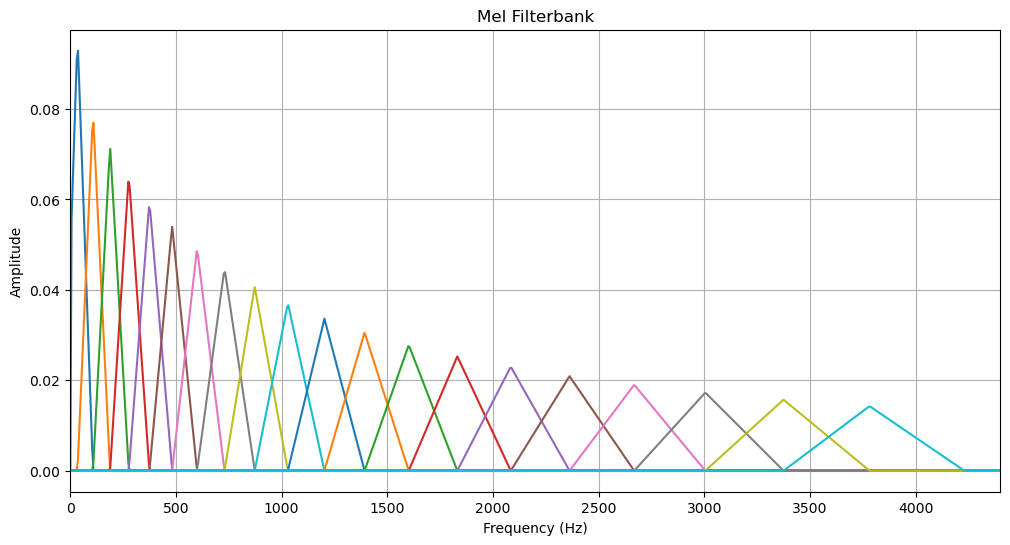

In [5]:
# --- Parameters
n_fft = 4096
fmax = 4000
mel_bands = 20
sobrep = 0.5     # filter overlap


"""
NOTE: The filter bank shown in the paper (Figure 1) incorrectly depicts 20% overlap.
The actual filter bank used in the original work — and reproduced here — uses 50% overlap,
which is consistent with the results reported in the paper.
"""

# --- Filterbank
mel_filters = mel_filterbank(
    fs, 
    mel_bands, 
    fmax, 
    sobrep, 
    n_fft, 
    print_filters=True
)



In [6]:
# --- Parameters
milisegundo = round(fs/1000)
tamanho = 30*milisegundo    # window
passo = 10*milisegundo      # step


# --- MEl Filterbank Magnitudes
mfbm_list = []

for sinal in df['signal']:
    mfbm = get_MFBM(sinal, fs, tamanho, passo, n_fft, mel_filters)
    mfbm_list.append(mfbm)

df['MFBM'] = mfbm_list


In [7]:
# Extract acoustic features 
# Only Jitter, Shimmer and HNR are used here

df = extract_voice_features(df)


# Verifying values
print(df[["localJitter", "localShimmer", "HNR"]].describe())

print()

# Verifying for invalid values
for col in ["localJitter", "localShimmer", "HNR"]:
    print(f"{col}:")
    print("NaN:", np.isnan(df[col]).sum())
    print("Inf:", np.isinf(df[col]).sum())
    print()

       localJitter  localShimmer         HNR
count   149.000000    149.000000  149.000000
mean      0.008762      0.058604   17.288140
std       0.012110      0.051429    7.368796
min       0.001044      0.007392   -0.720693
25%       0.002951      0.023899   13.188274
50%       0.004597      0.039617   17.915258
75%       0.009487      0.076977   22.911661
max       0.083315      0.299317   30.921246

localJitter:
NaN: 0
Inf: 0

localShimmer:
NaN: 0
Inf: 0

HNR:
NaN: 0
Inf: 0



In [8]:
# resetting df index
#df = df.reset_index(drop=True)

# exporting
df2 = export_dataframe(
    df,
    dataset_name="mysMEEI",
    drop_columns=['signal', 'MFBM', 'path', 'fs', 'meanF0', 'stddevF0']
)

print(df2.columns)

Saved to: ..\data\processed\mysMEEI.parquet
Index(['file', 'age', 'gender', 'group', 'class', 'localJitter',
       'localShimmer', 'HNR', 'MFBM_0', 'MFBM_1', 'MFBM_2', 'MFBM_3', 'MFBM_4',
       'MFBM_5', 'MFBM_6', 'MFBM_7', 'MFBM_8', 'MFBM_9', 'MFBM_10', 'MFBM_11',
       'MFBM_12', 'MFBM_13', 'MFBM_14', 'MFBM_15', 'MFBM_16', 'MFBM_17',
       'MFBM_18', 'MFBM_19'],
      dtype='object')
